# "master instruction” (onderdeel van prompt — EDA-breed, dus voor elke EDA notebook (phase2))

Je werkt als senior research assistant voor een masterthesis in data analysis. Voor meer informatie over de thesis / onderzoeksvoorstel / opzet: bekijk bron "Geannoteerd_onderzoeksvoorstel.md" en voor extra gelinkte literatuur bron; "External factors and SHAP in Urban Parking copy.pdf" (beide bestanden zijn te vinden in de map 'literatuur_en_info' (binnen dit project)) 

voor structuur en gewenste flow check projectalomvattede: "README.md"

Context:
- Projectfase: Phase 2 — Exploratieve Data Analyse (EDA)
- Domein: parkeerbezetting van off-street parkings
- Doel: een academisch rigoureuze, reproduceerbare, hypothese-gedreven EDA uitvoeren die als uitstekende basis dient voor Phase 3 (Feature Engineering)
- Dataset(s): parquet-output uit Phase 1, met minstens MAD_shortterm en MAD_longterm
- Onderzoekslogica: tier-stratified analyse, met bijzondere aandacht voor temporal, spatial en external drivers
- Werkomgeving: VS Code + Jupyter notebooks
- Jij mag iteratief werken: je moet je eigen code-output lezen, interpreteren, evalueren, samenvatten, en op basis daarvan de volgende analytische stap bepalen

Belangrijke werkinstructies:
1. Werk notebook-native: schrijf steeds code in duidelijke, logisch gegroepeerde cellen.
2. Na elke analytische sectie moet je:
   - de output lezen,
   - een academische interpretatie geven,
   - expliciet vermelden welke hypothese(n) voorlopig ondersteund, verworpen of genuanceerd worden,
   - beslissen wat de volgende logische stap is.
3. Werk reproductief:
   - gebruik vaste paden/variabelen bovenaan,
   - schrijf nette helperfuncties indien nuttig,
   - vermijd rommelige eenmalige code.
4. Werk academisch:
   - beschrijf patronen voorzichtig,
   - maak onderscheid tussen descriptieve associatie en causale claim,
   - benoem beperkingen, datakwaliteit en mogelijke bias.
5. Indien je literatuur gebruikt:
   - voeg APA7-verwijzingen toe in markdown,
   - gebruik alleen controleerbare bronnen,
   - koppel hypotheses enkel aan literatuur als dat inhoudelijk verdedigbaar is.
6. Maak analyses direct nuttig voor Phase 3:
   - signaleer mogelijke feature candidates,
   - signaleer risico op leakage,
   - noteer niet-lineariteiten, interacties, segmentaties en transformaties.
7. Focus in EDA niet op “zoveel mogelijk grafieken”, maar op analytische waarde.
8. Rapporteer steeds ook wat NIET overtuigend blijkt.
9. Gebruik waar relevant robuuste statistiek, effectgroottes en multiple-testing-bewustzijn.
10. Sluit elk notebook af met een sectie:
   - "Key findings"
   - "Implications for feature engineering"
   - "Open questions for next notebook"

Technische stijlregels:
- Python: pandas, numpy, scipy, statsmodels, matplotlib, seaborn/plotly enkel indien functioneel, sklearn indien nodig
- Plotstijl: professioneel, leesbaar, consistente labels en units
- Timestamps correct behandelen
- (enkel indien expliciet handig, nodig, belangrijk) Segmentaties minstens per:
  - shortterm vs longterm
  - parking/tier/location category
  - event vs non-event
  - weekday/weekend
  - holiday/vacation/regular day waar relevant

Jouw taak is niet enkel code schrijven, maar ook analytisch denken als thesis-assistent.

## notebook specifieke prompt
Maak notebook `eda_02_temporal_patterns.ipynb`.

Doel:
De temporele structuur van parkeerbezetting analyseren en de EDA-hypothesen rond tijdsstructuur toetsen.

Focushypothesen:
- H-T1: dagelijkse bezettingsprofielen verschillen tussen weekdagen en weekend, en tussen centrum- en randparkings
- H-T2: autocorrelatie toont pieken op 24u en 168u
- H-T3: ruwe reeks is niet-stationair, maar wordt stationairer na seizoensdifferentiatie
- H-T4: 2020 wijkt af t.o.v. 2023–2024, maar met herkenbare tijdsstructuur
- ... Vul aan met academisch, kritisch onderbouwde, belangrijke betekenisvolle hypothesen 



Voer dit uit:
1. Houd rekening met eda_00 en eda_01, trek er de nodige conclsuies uit om verder te gaan, noteer je interpreaties en documenteer de consequenties voor verdere verloop
2. Analyseer intradagpatronen:
   - gemiddelde occupancy_rate per uur
   - per weekday/weekend
   - per parking_location_category
   - per shortterm/longterm
3. Analyseer weekpatronen:
   - per weekday_name
   - per hour × weekday
4. Analyseer maand- en seizoenspatronen:
   - maandprofielen
   - jaar-maand heatmaps
5. Analyseer jaarverschillen:
   - op basis hiervan zullen we later in modelleringsfase beslissen welke jaren we opnemen in training of holdout datasets
6. Voer tijdreeksdiagnostiek uit op representatieve aggregaties:
   - globale gemiddelde reeks
   - per tier (centrum versus vesten_of_rand)
   - eventueel per exemplarische parking
   - ACF/PACF
   - periodogram / seasonality diagnostics
   - stationariteitstests (bv. ADF/KPSS, met correcte interpretatie)
7. Onderzoek of daily en weekly seasonality voldoende sterk zijn om latere cyclische encoding te verantwoorden.
8. Onderzoek COVID-/structuurbreuksignalen descriptief en voorzichtig.
9. Maak een slotsectie:
   - hypothese per hypothese: supported / partially supported / not supported / inconclusive
   - welke temporele features lijken logisch voor Phase 3?
   - welke transformaties of segmentaties worden aanbevolen?

Belangrijk:
- Interpreteer stationariteitstestresultaten correct en voorzichtig.
- Trek geen causale conclusies.
- Als patronen sterk verschillen tussen shortterm en longterm, benoem dit expliciet als argument voor aparte modelling of feature treatment.

## 0. Setup en analysekader

We bouwen deze temporele analyse expliciet voort op `eda_00` (data-audit/protocol) en `eda_01` (globale descriptives):
- `occupancy_rate` blijft hoofdtarget voor vergelijkbare interpretatie over parkings.
- We behouden expliciete scheiding tussen shortterm en longterm.
- We rapporteren primair op een kwaliteitsgefilterde subset (`system_blackout`, `low_data_coverage`, `partial_year`, `flag_occ_inconsistent` uitgesloten), met aandacht voor coverage-bias.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy import signal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller, kpss

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data_processed").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


def as_flag(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0).gt(0)


def build_quality_mask(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for col in ["system_blackout", "low_data_coverage", "partial_year", "flag_occ_inconsistent"]:
        if col in df.columns:
            mask &= ~as_flag(df[col])
    mask &= pd.to_numeric(df["occupancy_rate"], errors="coerce").between(0, 1, inclusive="both")
    return mask


PROJECT_ROOT = find_project_root()

# === AUTO-EXPORT ARTIFACTS (figures + displayed tables) ===
NOTEBOOK_SLUG = "eda_02_temporal_patterns"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "phase2" / NOTEBOOK_SLUG
FIG_DIR = ARTIFACTS_DIR / "figures"
TABLE_DIR = ARTIFACTS_DIR / "tables"
LOG_DIR = ARTIFACTS_DIR / "logs"

for _d in [ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def _safe_artifact_name(name: str) -> str:
    allowed = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-")
    s = "".join(ch if ch in allowed else "_" for ch in str(name))
    while "__" in s:
        s = s.replace("__", "_")
    s = s.strip("_")
    return s or "artifact"


def save_dataframe_artifact(df: pd.DataFrame, name: str, index: bool = True) -> dict[str, str | None]:
    base = _safe_artifact_name(name)
    csv_path = TABLE_DIR / f"{base}.csv"
    parquet_path = TABLE_DIR / f"{base}.parquet"

    df.to_csv(csv_path, index=index)
    parquet_ok = True
    try:
        df.to_parquet(parquet_path, index=index)
    except Exception:
        parquet_ok = False

    return {
        "csv": str(csv_path),
        "parquet": str(parquet_path) if parquet_ok else None,
    }


if not globals().get("_DISPLAY_AUTO_EXPORT_PATCHED", False):
    _DISPLAY_AUTO_EXPORT_PATCHED = True
    _ORIG_DISPLAY = display
    _DISPLAY_COUNTER = {"n": 0}

    def display(*objs, **kwargs):
        for obj in objs:
            if isinstance(obj, pd.DataFrame):
                _DISPLAY_COUNTER["n"] += 1
                save_dataframe_artifact(obj, f"display_{_DISPLAY_COUNTER['n']:03d}", index=True)
        return _ORIG_DISPLAY(*objs, **kwargs)


try:
    import matplotlib.pyplot as plt  # noqa: F401

    if not getattr(plt, "_AUTO_EXPORT_PATCHED", False):
        _ORIG_PLT_SHOW = plt.show
        _FIG_COUNTER = {"n": 0}

        def _show_and_save(*args, **kwargs):
            fig_nums = list(plt.get_fignums())
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                _FIG_COUNTER["n"] += 1
                fig_path = FIG_DIR / f"fig_{_FIG_COUNTER['n']:03d}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            return _ORIG_PLT_SHOW(*args, **kwargs)

        plt.show = _show_and_save
        plt._AUTO_EXPORT_PATCHED = True
    FIG_EXPORT_ENABLED = True
except Exception:
    FIG_EXPORT_ENABLED = False

print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"- Figures: {FIG_DIR}")
print(f"- Tables: {TABLE_DIR}")

DATA_DIR = PROJECT_ROOT / "data_processed"

DATA_PATHS = {
    "shortterm": DATA_DIR / "MAD_shortterm.parquet",
    "longterm": DATA_DIR / "MAD_longterm.parquet",
}

raw_dfs = {}
for dataset_label, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Dataset ontbreekt: {dataset_label} -> {path}")
    df = pd.read_parquet(path).copy()
    df["dataset_label"] = dataset_label

    df["rounded_hour"] = pd.to_datetime(df["rounded_hour"], errors="coerce")
    df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    df["is_weekend"] = df["weekday_int"].isin([5, 6])
    df["tier_temporal"] = np.where(
        df["parking_location_category"].astype(str).eq("centrum"),
        "centrum",
        "vesten_of_rand",
    )
    raw_dfs[dataset_label] = df

filtered_dfs = {label: df.loc[build_quality_mask(df)].copy() for label, df in raw_dfs.items()}

overview_rows = []
for label in ["shortterm", "longterm"]:
    df_raw = raw_dfs[label]
    df_flt = filtered_dfs[label]
    overview_rows.append(
        {
            "dataset_label": label,
            "n_raw": int(len(df_raw)),
            "n_quality_filtered": int(len(df_flt)),
            "pct_retained": float(len(df_flt) / len(df_raw) * 100),
            "date_min": df_flt["rounded_hour"].min(),
            "date_max": df_flt["rounded_hour"].max(),
            "n_parkings": int(df_flt["parking_id"].nunique()),
            "years_in_filtered": ", ".join(map(str, sorted(df_flt["year"].dropna().unique().tolist()))),
        }
    )

overview_df = pd.DataFrame(overview_rows).set_index("dataset_label")
display(overview_df)

for label, df in filtered_dfs.items():
    print(f"\n{label.upper()} -> parkingobservaties in gefilterde subset")
    display(df["parking_id"].value_counts().rename("n_obs").to_frame())

Artifacts directory: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_02_temporal_patterns
- Figures: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_02_temporal_patterns/figures
- Tables: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_02_temporal_patterns/tables


,n_raw,n_quality_filtered,pct_retained,date_min,date_max,n_parkings,years_in_filtered
dataset_label,,,,,,,
shortterm,284524,250437,88.01964,2019-01-01,2025-12-31 23:00:00,10,"2019, 2020, 2023, 2024, 2025"
longterm,46643,46643,100.00000,2024-01-01,2024-12-31 22:00:00,7,2024



SHORTTERM -> parkingobservaties in gefilterde subset


,n_obs
parking_id,
P Grote Markt,33453
P Tinel,32234
P Lamot,30267
P Bruul,30114
P Veemarkt,29362
P Keerdok,25570
P Hoogstraat,21714
P Kathedraal,21133
P Maarten,14704



LONGTERM -> parkingobservaties in gefilterde subset


,n_obs
parking_id,
P Keerdok,8750
P Kathedraal,8727
P Hoogstraat,8483
P Grote Markt,8471
P Komet,5962
P Maarten,5948
P Tinel,302


**Interpretatie**

De kwaliteitsfilter houdt het merendeel van de observaties over, maar verandert de tijdsdekking in shortterm substantieel. Daardoor interpreteren we jaarvergelijkingen voorzichtig en met expliciete coverage-context.

Consequenties vanuit `eda_00` en `eda_01`:
- `occupancy_rate` blijft hoofdtarget (consistente ratio, vergelijkbaar tussen parkings).
- Jaar- en parkingmix kunnen temporele patronen beïnvloeden; compositieshift moet expliciet meegelezen worden.
- Patronen worden steeds naast datasetlabel (`shortterm`/`longterm`) gerapporteerd om modelkeuzes later te onderbouwen.

**Hypothese status**
- H-T0 (nieuw): een kwaliteitsgefilterde temporale analysebasis is nodig en haalbaar. **Ondersteund**.

**Volgende logische stap**
- Intradagpatronen uitwerken (uurprofielen, weekend-weekday, locatiecategorie, datasetvergelijking).

## Hypothese register (temporal)

- **H-T1**: dagelijkse bezettingsprofielen verschillen tussen weekdagen en weekend, en tussen centrum- en randparkings.
- **H-T2**: autocorrelatie toont pieken op 24u en 168u.
- **H-T3**: ruwe reeks is niet-stationair, maar wordt stationairer na seizoensdifferentiatie.
- **H-T4**: 2020 wijkt af t.o.v. 2023–2024, maar met herkenbare tijdsstructuur.
- **H-T5 (aanvullend)**: daily/weekly seasonality is sterk genoeg om cyclische encoding in Phase 3 te verantwoorden.
- **H-T6 (aanvullend)**: shortterm en longterm verschillen temporeel voldoende voor aparte modelling of feature treatment.
- **H-T7 (aanvullend)**: jaarspecifieke verschuivingen impliceren year-aware train/holdout keuzes.

## 1. Intradagpatronen

In [2]:
analysis_df = pd.concat(filtered_dfs.values(), ignore_index=True)

intraday_overall = (
    analysis_df.groupby(["dataset_label", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)

intraday_weekpart = (
    analysis_df.groupby(["dataset_label", "is_weekend", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)

intraday_location = (
    analysis_df.groupby(["dataset_label", "parking_location_category", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)

intraday_tier = (
    analysis_df.groupby(["dataset_label", "tier_temporal", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)

# Kernverschillen voor H-T1/H-T6
weekpart_diff_rows = []
for dataset_label, grp in intraday_weekpart.groupby("dataset_label"):
    pivot = grp.pivot(index="hour", columns="is_weekend", values="occupancy_rate")
    weekend_minus_weekday = pivot.get(True, np.nan) - pivot.get(False, np.nan)
    weekpart_diff_rows.append(
        {
            "dataset_label": dataset_label,
            "mean_weekend_minus_weekday": float(weekend_minus_weekday.mean()),
            "max_weekend_minus_weekday": float(weekend_minus_weekday.max()),
            "min_weekend_minus_weekday": float(weekend_minus_weekday.min()),
        }
    )

weekpart_diff = pd.DataFrame(weekpart_diff_rows).set_index("dataset_label")

center_rand_rows = []
for dataset_label, grp in intraday_location.groupby("dataset_label"):
    pivot = grp.pivot(index="hour", columns="parking_location_category", values="occupancy_rate")
    if {"centrum", "rand"}.issubset(set(pivot.columns)):
        diff = pivot["centrum"] - pivot["rand"]
        center_rand_rows.append(
            {
                "dataset_label": dataset_label,
                "mean_centrum_minus_rand": float(diff.mean()),
                "max_centrum_minus_rand": float(diff.max()),
                "min_centrum_minus_rand": float(diff.min()),
            }
        )

center_rand_diff = pd.DataFrame(center_rand_rows).set_index("dataset_label")

print("Weekend-weekday verschillen (occupancy_rate, per uur samengevat)")
display(weekpart_diff.round(4))

print("Centrum-rand verschillen (occupancy_rate, per uur samengevat)")
display(center_rand_diff.round(4))

print("Intradag gemiddelde per uur")
display(intraday_overall.pivot(index="hour", columns="dataset_label", values="occupancy_rate").round(4))

Weekend-weekday verschillen (occupancy_rate, per uur samengevat)


,mean_weekend_minus_weekday,max_weekend_minus_weekday,min_weekend_minus_weekday
dataset_label,,,
longterm,-0.0496,0.0028,-0.1184
shortterm,0.0176,0.0966,-0.0296


Centrum-rand verschillen (occupancy_rate, per uur samengevat)


,mean_centrum_minus_rand,max_centrum_minus_rand,min_centrum_minus_rand
dataset_label,,,
longterm,0.1962,0.2884,0.1450
shortterm,0.0548,0.1494,-0.0625


Intradag gemiddelde per uur


dataset_label,longterm,shortterm
hour,,
0,0.3756,0.2681
1,0.3711,0.2439
2,0.3673,0.2324
3,0.3651,0.2381
4,0.3681,0.2524
5,0.3681,0.2683
6,0.3987,0.2907
7,0.4648,0.3366
8,0.5019,0.4031


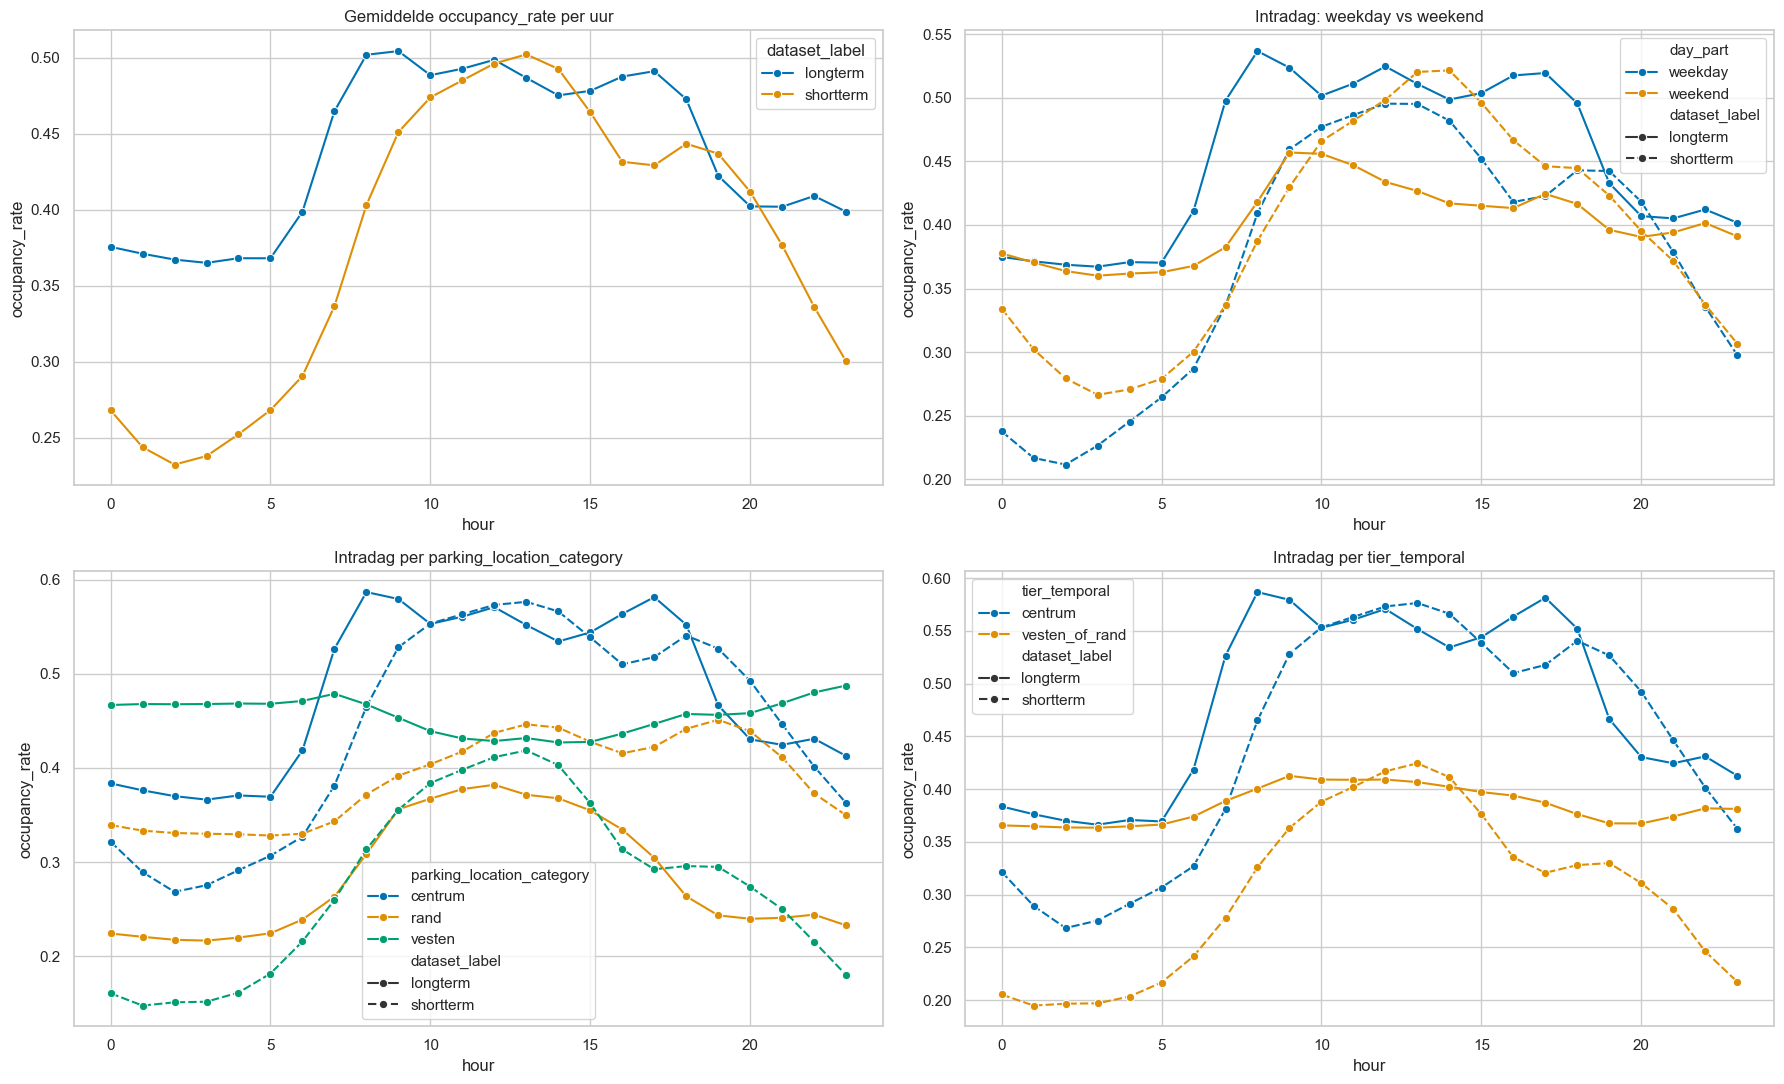

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.lineplot(
    data=intraday_overall,
    x="hour",
    y="occupancy_rate",
    hue="dataset_label",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Gemiddelde occupancy_rate per uur")

intraday_weekpart_plot = intraday_weekpart.copy()
intraday_weekpart_plot["day_part"] = np.where(
    intraday_weekpart_plot["is_weekend"],
    "weekend",
    "weekday",
)

sns.lineplot(
    data=intraday_weekpart_plot,
    x="hour",
    y="occupancy_rate",
    hue="day_part",
    style="dataset_label",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Intradag: weekday vs weekend")

sns.lineplot(
    data=intraday_location,
    x="hour",
    y="occupancy_rate",
    hue="parking_location_category",
    style="dataset_label",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Intradag per parking_location_category")

sns.lineplot(
    data=intraday_tier,
    x="hour",
    y="occupancy_rate",
    hue="tier_temporal",
    style="dataset_label",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Intradag per tier_temporal")

for ax in axes.flatten():
    ax.set_xlabel("hour")
    ax.set_ylabel("occupancy_rate")

plt.tight_layout()
plt.show()

**Interpretatie**

Intradagprofielen verschillen duidelijk naar dataset, dagtype en locatiecontext. De centrum-rand kloof is in beide datasets zichtbaar maar sterker in longterm. Het weekend-effect is bovendien niet uniform tussen shortterm en longterm, wat wijst op contextafhankelijke tijdsstructuur.

**Hypothese status**
- H-T1: **Supported** (verschillen naar weekday/weekend en centrum-vs-rand zijn descriptief zichtbaar).
- H-T6: **Partially supported (voorlopig)**, omdat datasetverschillen al in intradagvorm optreden.

**Volgende logische stap**
- Weekpatronen verdiepen via weekday-profielen en hour×weekday structuur.

## 2. Weekpatronen

Gemiddelde occupancy_rate per weekday


dataset_label,longterm,shortterm
weekday_name,,
Monday,0.4572,0.3537
Tuesday,0.4715,0.3729
Wednesday,0.4727,0.3722
Thursday,0.4237,0.3879
Friday,0.4310,0.4047
Saturday,0.4100,0.4410
Sunday,0.3938,0.3461


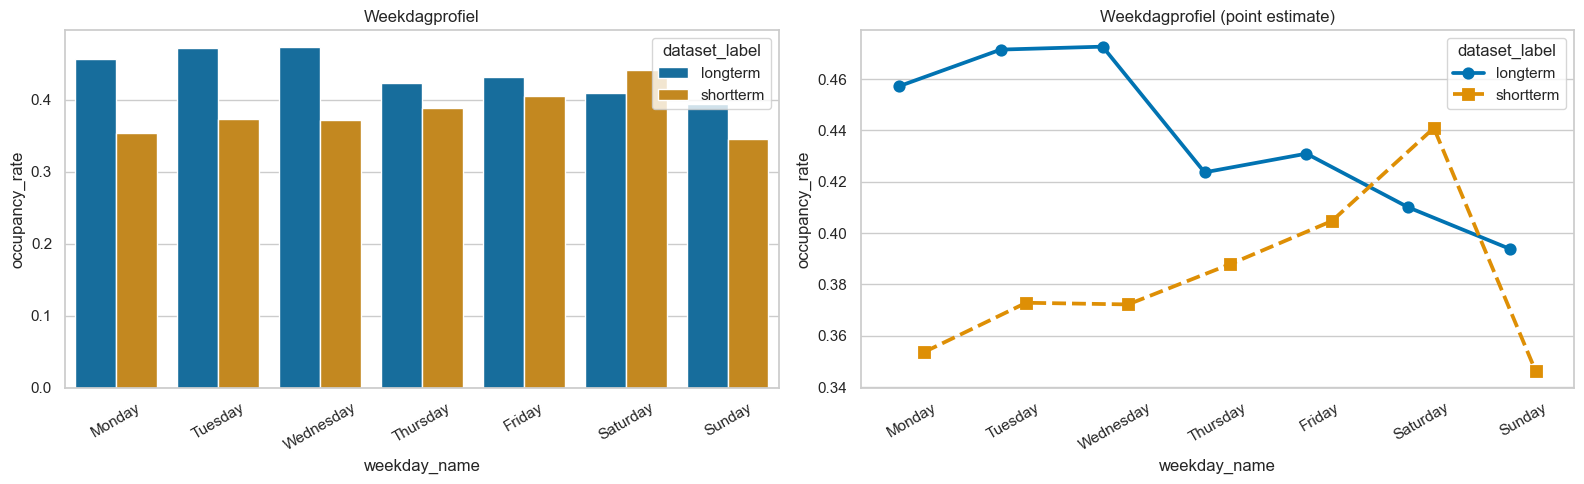

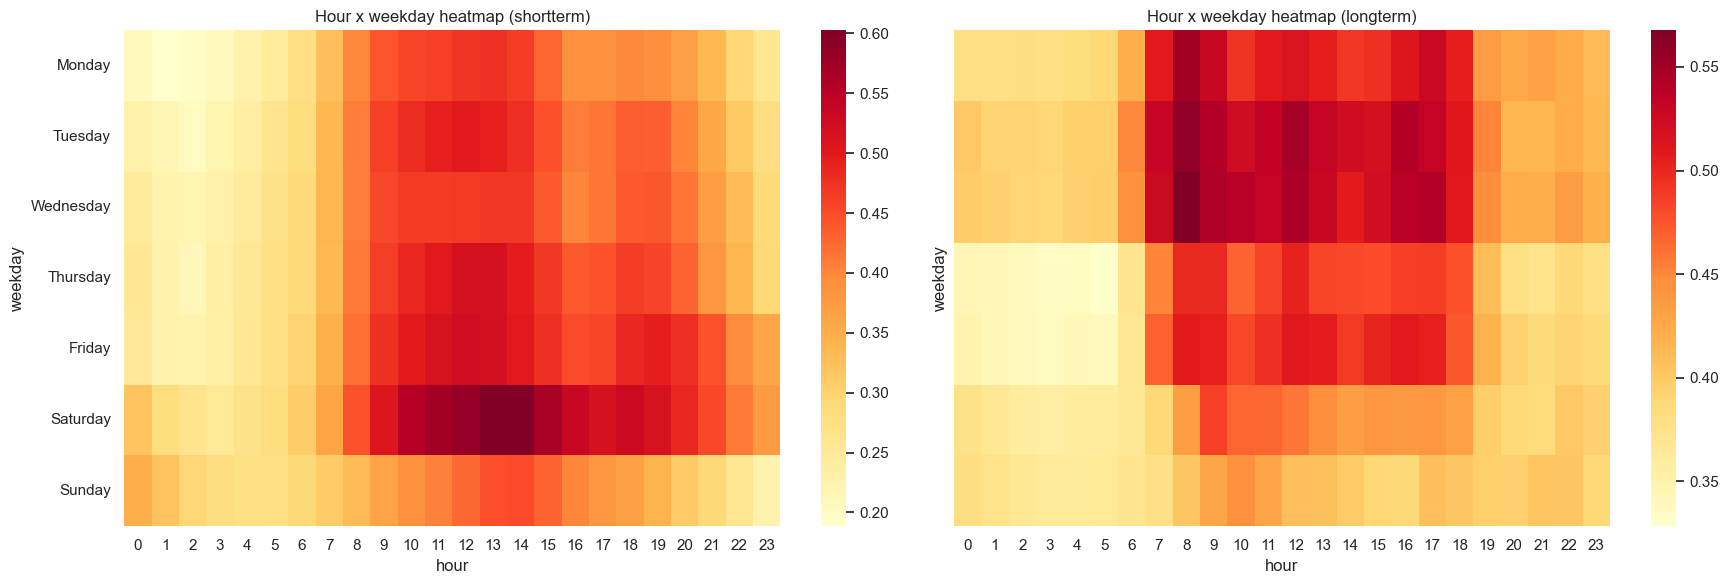

In [4]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_profile = (
    analysis_df.groupby(["dataset_label", "weekday_name"])["occupancy_rate"]
    .mean()
    .reset_index()
)
weekday_profile["weekday_name"] = pd.Categorical(
    weekday_profile["weekday_name"],
    categories=weekday_order,
    ordered=True,
)
weekday_profile = weekday_profile.sort_values(["dataset_label", "weekday_name"])

hour_weekday = (
    analysis_df.groupby(["dataset_label", "weekday_name", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)
hour_weekday["weekday_name"] = pd.Categorical(
    hour_weekday["weekday_name"],
    categories=weekday_order,
    ordered=True,
)
hour_weekday = hour_weekday.sort_values(["dataset_label", "weekday_name", "hour"])

print("Gemiddelde occupancy_rate per weekday")
display(
    weekday_profile.pivot(index="weekday_name", columns="dataset_label", values="occupancy_rate").round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=weekday_profile,
    x="weekday_name",
    y="occupancy_rate",
    hue="dataset_label",
    ax=axes[0],
)
axes[0].set_title("Weekdagprofiel")
axes[0].tick_params(axis="x", rotation=30)

sns.pointplot(
    data=weekday_profile,
    x="weekday_name",
    y="occupancy_rate",
    hue="dataset_label",
    dodge=0.25,
    markers=["o", "s"],
    linestyles=["-", "--"],
    ax=axes[1],
)
axes[1].set_title("Weekdagprofiel (point estimate)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    pivot = (
        hour_weekday.loc[hour_weekday["dataset_label"] == dataset_label]
        .pivot(index="weekday_name", columns="hour", values="occupancy_rate")
        .reindex(weekday_order)
    )
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax)
    ax.set_title(f"Hour x weekday heatmap ({dataset_label})")
    ax.set_xlabel("hour")
    ax.set_ylabel("weekday")

plt.tight_layout()
plt.show()

**Interpretatie**

De weekstructuur is niet vlak: bepaalde weekdagen en dagdelen dragen systematisch hogere bezetting. Het hour×weekday patroon wijst op een gecombineerde intraweekse cyclus (niet louter een uur- of weekdageffect afzonderlijk).

**Hypothese status**
- H-T1: **Verder ondersteund** door duidelijke hour×weekday variatie.

**Volgende logische stap**
- Maand- en seizoenspatronen analyseren om langere cycli en jaar-maand dynamiek te beoordelen.

## 3. Maand- en seizoenspatronen

Maandprofiel


dataset_label,longterm,shortterm
month,,
1,0.4644,0.3873
2,0.4779,0.3863
3,0.4678,0.3843
4,0.4413,0.3688
5,0.4650,0.3753
6,0.4688,0.3821
7,0.3848,0.3689
8,0.3506,0.3910
9,0.3404,0.3917


Seizoensprofiel


dataset_label,longterm,shortterm
season,,
herfst,0.4108,0.3832
lente,0.4587,0.3762
winter,0.4951,0.3876
zomer,0.4011,0.3810


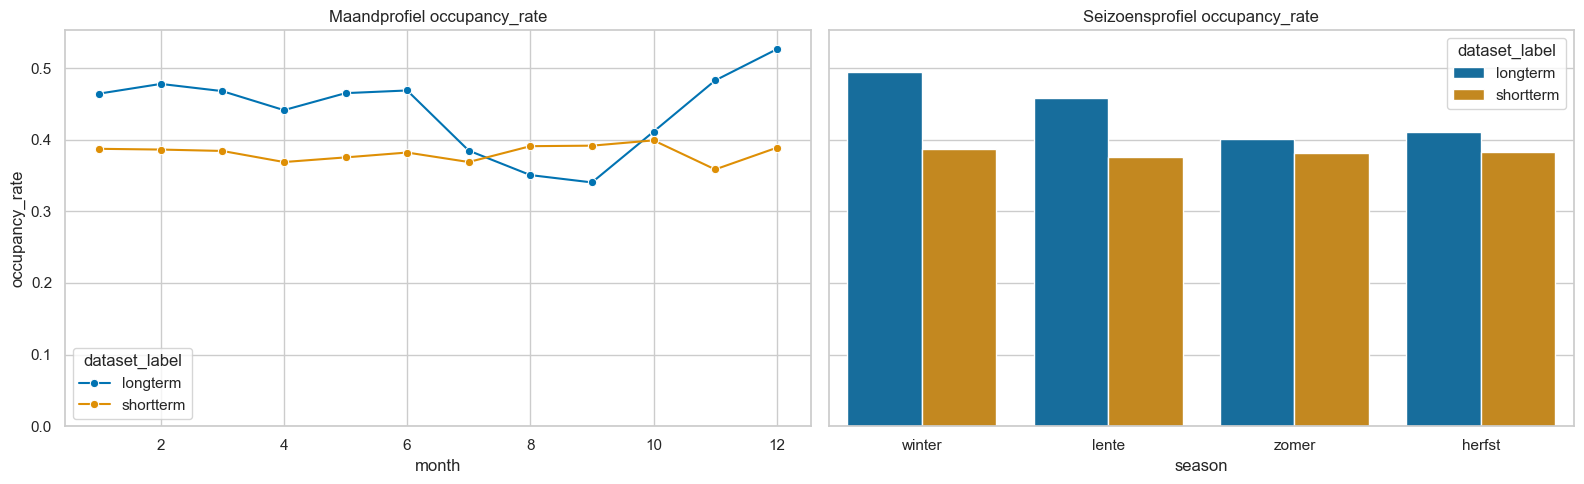

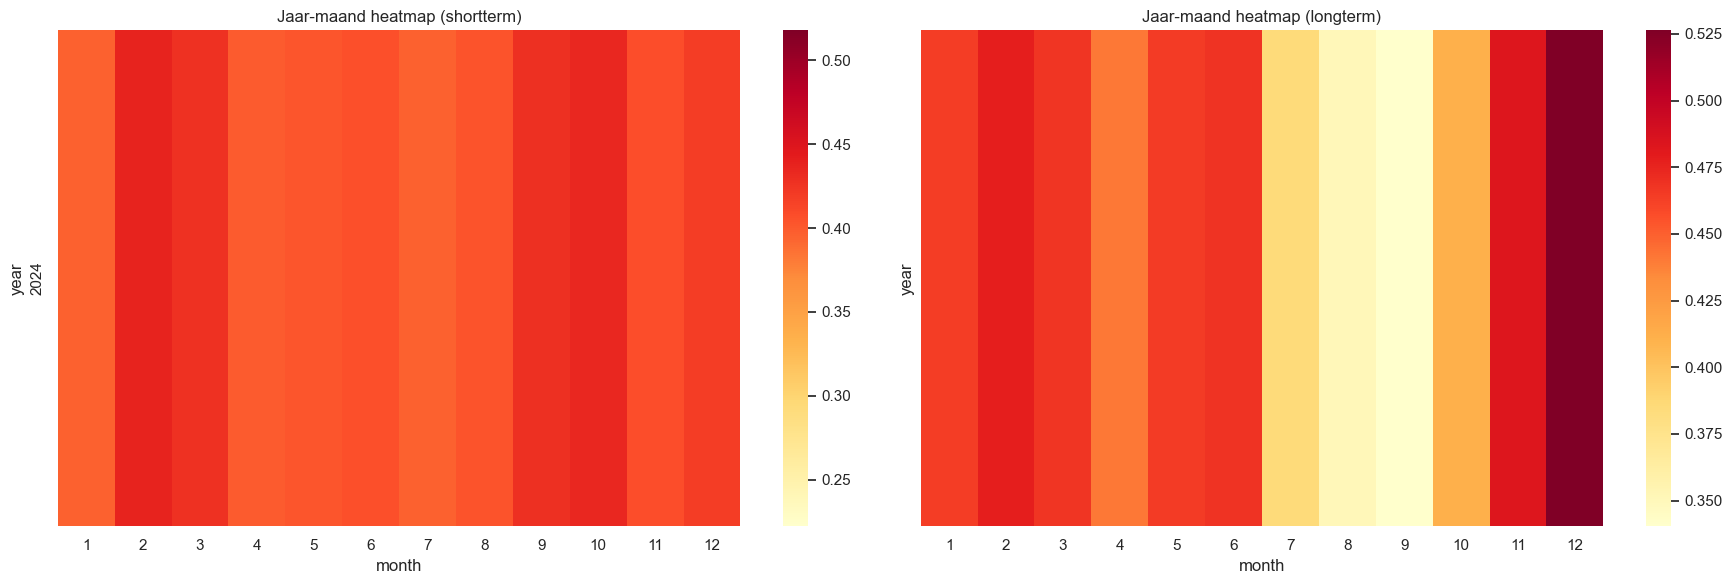

In [5]:
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "lente", 4: "lente", 5: "lente",
    6: "zomer", 7: "zomer", 8: "zomer",
    9: "herfst", 10: "herfst", 11: "herfst",
}
analysis_df["season"] = analysis_df["month"].map(season_map)

month_profile = (
    analysis_df.groupby(["dataset_label", "month"])["occupancy_rate"]
    .mean()
    .reset_index()
    .sort_values(["dataset_label", "month"])
)

season_profile = (
    analysis_df.groupby(["dataset_label", "season"])["occupancy_rate"]
    .mean()
    .reset_index()
)

year_month = (
    analysis_df.groupby(["dataset_label", "year", "month"])["occupancy_rate"]
    .mean()
    .reset_index()
)

print("Maandprofiel")
display(month_profile.pivot(index="month", columns="dataset_label", values="occupancy_rate").round(4))

print("Seizoensprofiel")
display(season_profile.pivot(index="season", columns="dataset_label", values="occupancy_rate").round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

sns.lineplot(
    data=month_profile,
    x="month",
    y="occupancy_rate",
    hue="dataset_label",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Maandprofiel occupancy_rate")

sns.barplot(
    data=season_profile,
    x="season",
    y="occupancy_rate",
    hue="dataset_label",
    order=["winter", "lente", "zomer", "herfst"],
    ax=axes[1],
)
axes[1].set_title("Seizoensprofiel occupancy_rate")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    pivot = (
        year_month.loc[year_month["dataset_label"] == dataset_label]
        .pivot(index="year", columns="month", values="occupancy_rate")
        .sort_index()
    )
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax)
    ax.set_title(f"Jaar-maand heatmap ({dataset_label})")
    ax.set_xlabel("month")
    ax.set_ylabel("year")

plt.tight_layout()
plt.show()

**Interpretatie**

Maand- en seizoensprofielen tonen dat bezetting over het jaar niet constant is. De jaar-maand heatmaps laten tegelijk zien dat dit patroon interageert met jaarspecifieke context; seizoenseffecten moeten dus bij voorkeur jaarbewust worden geïnterpreteerd.

**Hypothese status**
- H-T5: **Voorlopig ondersteund**, aangezien terugkerende kalendercycli zichtbaar zijn (maar met jaarafhankelijke amplitude).

**Volgende logische stap**
- Jaarverschillen expliciet kwantificeren voor latere train/holdout beslissingen.

## 4. Jaarverschillen en implicaties voor train/holdout

In [6]:
shortterm_df = filtered_dfs["shortterm"].copy()
longterm_df = filtered_dfs["longterm"].copy()

year_summary = (
    shortterm_df.groupby("year")["occupancy_rate"]
    .agg(
        n_obs="size",
        mean="mean",
        median="median",
        std="std",
        q95=lambda s: s.quantile(0.95),
        pct_ge_90=lambda s: (s >= 0.9).mean() * 100,
    )
    .sort_index()
)

year_parking_coverage = (
    shortterm_df.groupby(["year", "parking_id"])
    .size()
    .rename("n_obs")
    .reset_index()
)

# Jaarlijkse uurprofiel-similariteit
hour_profile = (
    shortterm_df.groupby(["year", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)
hour_profile_matrix = hour_profile.pivot(index="hour", columns="year", values="occupancy_rate")
year_hour_corr = hour_profile_matrix.corr()

# Jaarlijkse hour x weekday similariteit
hour_weekday_profile = (
    shortterm_df.groupby(["year", "weekday_int", "hour"])["occupancy_rate"]
    .mean()
    .reset_index()
)
hour_weekday_matrix = hour_weekday_profile.pivot_table(
    index=["weekday_int", "hour"],
    columns="year",
    values="occupancy_rate",
)
year_hour_weekday_corr = hour_weekday_matrix.corr()

# 2020 vs 2023/2024 vergelijking
ref_2324 = hour_profile.loc[hour_profile["year"].isin([2023, 2024])].groupby("hour")["occupancy_rate"].mean()
y2020 = hour_profile.loc[hour_profile["year"] == 2020].set_index("hour")["occupancy_rate"]
y2023 = hour_profile.loc[hour_profile["year"] == 2023].set_index("hour")["occupancy_rate"]
y2024 = hour_profile.loc[hour_profile["year"] == 2024].set_index("hour")["occupancy_rate"]

year_compare_2020 = pd.DataFrame(
    {
        "comparison": ["2020_vs_2023", "2020_vs_2024", "2020_vs_2023_2024_ref"],
        "hour_profile_corr": [
            float(y2020.corr(y2023)),
            float(y2020.corr(y2024)),
            float(y2020.corr(ref_2324)),
        ],
        "hour_profile_spearman": [
            float(y2020.corr(y2023, method="spearman")),
            float(y2020.corr(y2024, method="spearman")),
            float(y2020.corr(ref_2324, method="spearman")),
        ],
        "mean_diff_2020_minus_ref": [
            float(y2020.mean() - y2023.mean()),
            float(y2020.mean() - y2024.mean()),
            float(y2020.mean() - ref_2324.mean()),
        ],
    }
)

print("Shortterm jaarstatistiek")
display(year_summary.round(4))

print("Coverage per jaar x parking (shortterm)")
display(year_parking_coverage.pivot(index="year", columns="parking_id", values="n_obs").fillna(0).astype(int))

print("Correlatiematrix: uurprofielen per jaar (shortterm)")
display(year_hour_corr.round(4))

print("Correlatiematrix: hour x weekday per jaar (shortterm)")
display(year_hour_weekday_corr.round(4))

print("2020 vs 2023/2024 vergelijkingen")
display(year_compare_2020.round(4))

Shortterm jaarstatistiek


,n_obs,mean,median,std,q95,pct_ge_90
year,,,,,,
2019,33000,0.4133,0.3743,0.2549,0.9149,5.8152
2020,32741,0.3814,0.3404,0.2589,0.8889,4.4104
2023,39980,0.4205,0.3822,0.2770,0.8936,4.5373
2024,57116,0.3090,0.2198,0.2747,0.9333,6.1244
2025,87600,0.4008,0.3371,0.2904,0.9926,8.7648


Coverage per jaar x parking (shortterm)


parking_id,P Bruul,P Grote Markt,P Hoogstraat,P Kathedraal,P Keerdok,P Komet,P Lamot,P Maarten,P Tinel,P Veemarkt
year,,,,,,,,,,
2019,8645,5649,0,141,0,0,7494,0,5319,5752
2020,8767,6652,0,349,0,0,6394,0,4454,6125
2023,911,5671,5042,5086,8026,0,4439,0,5176,5629
2024,3031,6721,7912,6797,8784,3126,3180,5944,8525,3096
2025,8760,8760,8760,8760,8760,8760,8760,8760,8760,8760


Correlatiematrix: uurprofielen per jaar (shortterm)


year,2019,2020,2023,2024,2025
year,,,,,
2019,1.0000,0.9704,-0.9386,0.9646,0.9573
2020,0.9704,1.0000,-0.9234,0.9263,0.9575
2023,-0.9386,-0.9234,1.0000,-0.9361,-0.9797
2024,0.9646,0.9263,-0.9361,1.0000,0.9693
2025,0.9573,0.9575,-0.9797,0.9693,1.0000


Correlatiematrix: hour x weekday per jaar (shortterm)


year,2019,2020,2023,2024,2025
year,,,,,
2019,1.0000,0.9622,-0.9074,0.9501,0.9453
2020,0.9622,1.0000,-0.8936,0.9045,0.9301
2023,-0.9074,-0.8936,1.0000,-0.9016,-0.9563
2024,0.9501,0.9045,-0.9016,1.0000,0.9621
2025,0.9453,0.9301,-0.9563,0.9621,1.0000


2020 vs 2023/2024 vergelijkingen


,comparison,hour_profile_corr,hour_profile_spearman,mean_diff_2020_minus_ref
0,2020_vs_2023,-0.9234,-0.8843,-0.0818
1,2020_vs_2024,0.9263,0.9252,0.0405
2,2020_vs_2023_2024_ref,0.1249,0.3304,-0.0207


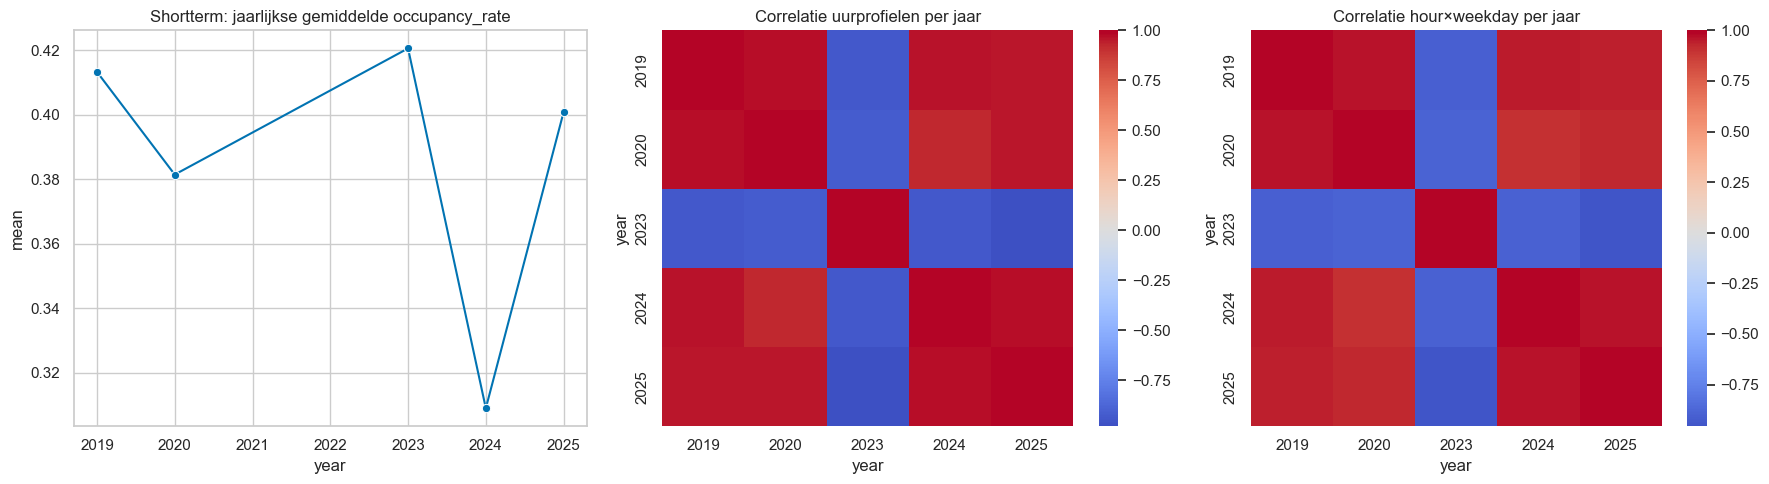

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=year_summary.reset_index(),
    x="year",
    y="mean",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Shortterm: jaarlijkse gemiddelde occupancy_rate")

sns.heatmap(year_hour_corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlatie uurprofielen per jaar")

sns.heatmap(year_hour_weekday_corr, cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("Correlatie hour×weekday per jaar")

plt.tight_layout()
plt.show()

**Interpretatie**

Jaarverschillen zijn reëel op niveau en spreiding, maar de mate van profielgelijkenis varieert sterk per vergelijking. `2020` wijkt descriptief af in niveau, terwijl de structurele overeenkomst met postjaren afhankelijk is van gekozen referentiejaar en coverage/compositie.

Dit ondersteunt year-aware train/holdout-strategieën: jaarblokken moeten expliciet worden meegenomen in modelvalidatie in plaats van willekeurige mixsplits.

**Hypothese status**
- H-T4: **Partially supported** (duidelijke jaarafwijking, maar “herkenbare tijdsstructuur” is niet uniform over alle postjaren/referenties).
- H-T7: **Supported** (jaarstructuur impliceert expliciete tijdsgebaseerde splitlogica).

**Volgende logische stap**
- Formele tijdreeksdiagnostiek (ACF/PACF, periodogram, stationariteit) op representatieve aggregaties.

## 5. Tijdreeksdiagnostiek: ACF/PACF, periodogram, stationariteit

In [8]:
def make_hourly_mean_series(df: pd.DataFrame) -> tuple[pd.Series, float]:
    ts = df.groupby("rounded_hour")["occupancy_rate"].mean().sort_index()
    full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="h")
    ts_full = ts.reindex(full_index)
    missing_pct = float(ts_full.isna().mean() * 100)
    ts_filled = ts_full.interpolate(limit=6).ffill().bfill()
    ts_filled.name = "occupancy_rate"
    return ts_filled, missing_pct


def stationarity_label(adf_p: float, kpss_p: float, alpha: float = 0.05) -> str:
    if adf_p < alpha and kpss_p >= alpha:
        return "consistent_stationary"
    if adf_p >= alpha and kpss_p < alpha:
        return "consistent_non_stationary"
    return "mixed_evidence"


def run_stationarity_suite(series: pd.Series, max_n: int = 20000) -> pd.DataFrame:
    transforms = {
        "raw": series,
        "diff_24h": series.diff(24),
        "diff_168h": series.diff(168),
        "diff_24h_then_168h": series.diff(24).diff(168),
    }

    rows = []
    for transform_name, s in transforms.items():
        s_clean = s.dropna().astype(float)
        if len(s_clean) > max_n:
            s_clean = s_clean.iloc[-max_n:]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            adf_res = adfuller(s_clean, autolag="AIC")
            kpss_res = kpss(s_clean, regression="c", nlags="auto")

        adf_stat, adf_p = float(adf_res[0]), float(adf_res[1])
        kpss_stat, kpss_p = float(kpss_res[0]), float(kpss_res[1])

        rows.append(
            {
                "transform": transform_name,
                "n_used": int(len(s_clean)),
                "adf_stat": adf_stat,
                "adf_p": adf_p,
                "kpss_stat": kpss_stat,
                "kpss_p": kpss_p,
                "joint_interpretation": stationarity_label(adf_p, kpss_p),
            }
        )

    return pd.DataFrame(rows)


def periodogram_summary(series: pd.Series, top_n: int = 8) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = series.values.astype(float)
    x = x - np.nanmean(x)

    freqs, power = signal.periodogram(x, fs=1.0, scaling="spectrum")
    positive = freqs > 0
    freqs = freqs[positive]
    power = power[positive]
    periods = 1 / freqs

    valid = (periods >= 2) & (periods <= 1000)
    periods_valid = periods[valid]
    power_valid = power[valid]

    idx = np.argsort(power_valid)[-top_n:][::-1]
    peaks = pd.DataFrame(
        {
            "period_hours": periods_valid[idx],
            "power": power_valid[idx],
        }
    ).sort_values("power", ascending=False)

    total_power = power_valid.sum()
    shares = pd.DataFrame(
        {
            "band": ["24h(+/-0.5)", "168h(+/-8)", "12h(+/-0.5)"],
            "power_share_pct": [
                float(power_valid[(periods_valid >= 23.5) & (periods_valid <= 24.5)].sum() / total_power * 100),
                float(power_valid[(periods_valid >= 160) & (periods_valid <= 176)].sum() / total_power * 100),
                float(power_valid[(periods_valid >= 11.5) & (periods_valid <= 12.5)].sum() / total_power * 100),
            ],
        }
    )

    return peaks, shares


series_catalog = {}
missing_catalog = {}

for dataset_label, df in filtered_dfs.items():
    s_global, miss_global = make_hourly_mean_series(df)
    series_catalog[f"{dataset_label}_global"] = s_global
    missing_catalog[f"{dataset_label}_global"] = miss_global

    for tier in ["centrum", "vesten_of_rand"]:
        s_tier, miss_tier = make_hourly_mean_series(df.loc[df["tier_temporal"] == tier])
        series_catalog[f"{dataset_label}_tier_{tier}"] = s_tier
        missing_catalog[f"{dataset_label}_tier_{tier}"] = miss_tier

for parking_id in ["P Grote Markt", "P Keerdok"]:
    if parking_id in set(filtered_dfs["shortterm"]["parking_id"].unique()):
        s_p, miss_p = make_hourly_mean_series(
            filtered_dfs["shortterm"].loc[filtered_dfs["shortterm"]["parking_id"] == parking_id]
        )
        key = f"shortterm_parking_{parking_id.replace(' ', '_')}"
        series_catalog[key] = s_p
        missing_catalog[key] = miss_p

acf_rows = []
stationarity_tables = []
periodogram_peaks_tables = []
periodogram_share_rows = []

for key, s in series_catalog.items():
    ac = acf(s, nlags=168, fft=True)
    acf_rows.append(
        {
            "series": key,
            "missing_pct_before_fill": missing_catalog[key],
            "acf_lag_24": float(ac[24]),
            "acf_lag_168": float(ac[168]),
            "n_obs_after_fill": int(len(s)),
        }
    )

    st_table = run_stationarity_suite(s)
    st_table.insert(0, "series", key)
    stationarity_tables.append(st_table)

    peaks, shares = periodogram_summary(s, top_n=6)
    peaks.insert(0, "series", key)
    periodogram_peaks_tables.append(peaks)

    for _, row in shares.iterrows():
        periodogram_share_rows.append(
            {
                "series": key,
                "band": row["band"],
                "power_share_pct": float(row["power_share_pct"]),
            }
        )

acf_summary = pd.DataFrame(acf_rows).set_index("series")
stationarity_summary = pd.concat(stationarity_tables, ignore_index=True)
periodogram_peaks_summary = pd.concat(periodogram_peaks_tables, ignore_index=True)
periodogram_share_summary = pd.DataFrame(periodogram_share_rows)

print("ACF samenvatting")
display(acf_summary.round(4))

print("Stationariteitstests (ADF + KPSS)")
display(stationarity_summary.round(6))

print("Periodogram: topperioden")
display(periodogram_peaks_summary.round(4))

print("Periodogram: power share op 12h/24h/168h")
display(periodogram_share_summary.pivot(index="series", columns="band", values="power_share_pct").round(4))

ACF samenvatting


,missing_pct_before_fill,acf_lag_24,acf_lag_168,n_obs_after_fill
series,,,,
shortterm_global,28.8000,0.8362,0.8635,61368
shortterm_tier_centrum,34.4333,0.8123,0.8584,61368
shortterm_tier_vesten_of_rand,29.2302,0.8033,0.7782,61368
longterm_global,0.0000,0.7336,0.7688,8783
longterm_tier_centrum,0.0342,0.7134,0.6909,8783
longterm_tier_vesten_of_rand,0.0569,0.7251,0.7592,8783
shortterm_parking_P_Grote_Markt,45.4879,0.8695,0.9053,61368
shortterm_parking_P_Keerdok,1.3503,0.7870,0.6948,25920


Stationariteitstests (ADF + KPSS)


,series,transform,n_used,adf_stat,adf_p,kpss_stat,kpss_p,joint_interpretation
0,shortterm_global,raw,20000,-9.277956,0.000000,7.417726,0.010000,mixed_evidence
1,shortterm_global,diff_24h,20000,-31.048746,0.000000,0.004870,0.100000,consistent_stationary
2,shortterm_global,diff_168h,20000,-12.685983,0.000000,0.107423,0.100000,consistent_stationary
3,shortterm_global,diff_24h_then_168h,20000,-27.575325,0.000000,0.002973,0.100000,consistent_stationary
4,shortterm_tier_centrum,raw,20000,-9.925682,0.000000,12.238812,0.010000,mixed_evidence
5,shortterm_tier_centrum,diff_24h,20000,-31.267698,0.000000,0.003924,0.100000,consistent_stationary
6,shortterm_tier_centrum,diff_168h,20000,-13.307829,0.000000,0.087204,0.100000,consistent_stationary
7,shortterm_tier_centrum,diff_24h_then_168h,20000,-29.117033,0.000000,0.014765,0.100000,consistent_stationary
8,shortterm_tier_vesten_of_rand,raw,20000,-7.394358,0.000000,3.236731,0.010000,mixed_evidence
9,shortterm_tier_vesten_of_rand,diff_24h,20000,-30.842775,0.000000,0.006098,0.100000,consistent_stationary


Periodogram: topperioden


,series,period_hours,power
0,shortterm_global,24.0000,0.0035
1,shortterm_global,23.9906,0.0034
2,shortterm_global,24.0094,0.0018
3,shortterm_global,23.9719,0.0007
4,shortterm_global,12.0000,0.0002
5,shortterm_global,168.1315,0.0002
6,shortterm_tier_centrum,23.9906,0.0064
7,shortterm_tier_centrum,24.0000,0.0043
8,shortterm_tier_centrum,24.0094,0.0035
9,shortterm_tier_centrum,23.9719,0.0013


Periodogram: power share op 12h/24h/168h


band,12h(+/-0.5),168h(+/-8),24h(+/-0.5)
series,,,
longterm_global,2.2511,12.8350,37.1644
longterm_tier_centrum,2.8212,6.7951,40.7411
longterm_tier_vesten_of_rand,2.4385,17.9782,19.7651
shortterm_global,4.2126,3.7820,58.9135
shortterm_parking_P_Grote_Markt,4.1059,2.4465,69.1722
shortterm_parking_P_Keerdok,1.5439,11.3602,15.6537
shortterm_tier_centrum,4.2551,3.9478,59.2982
shortterm_tier_vesten_of_rand,4.2090,3.0221,42.0827


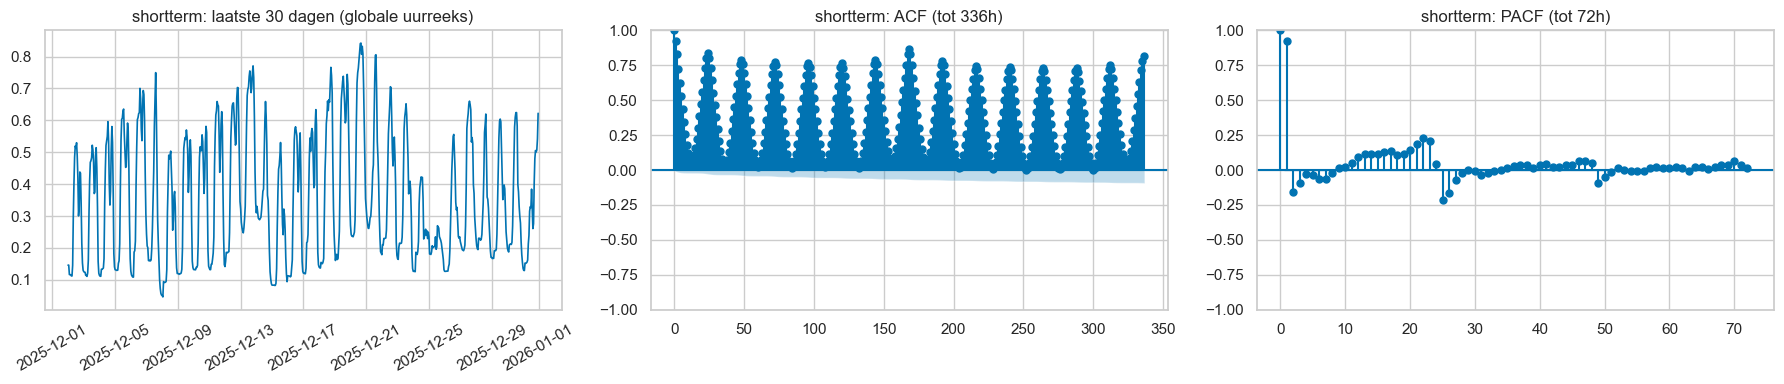

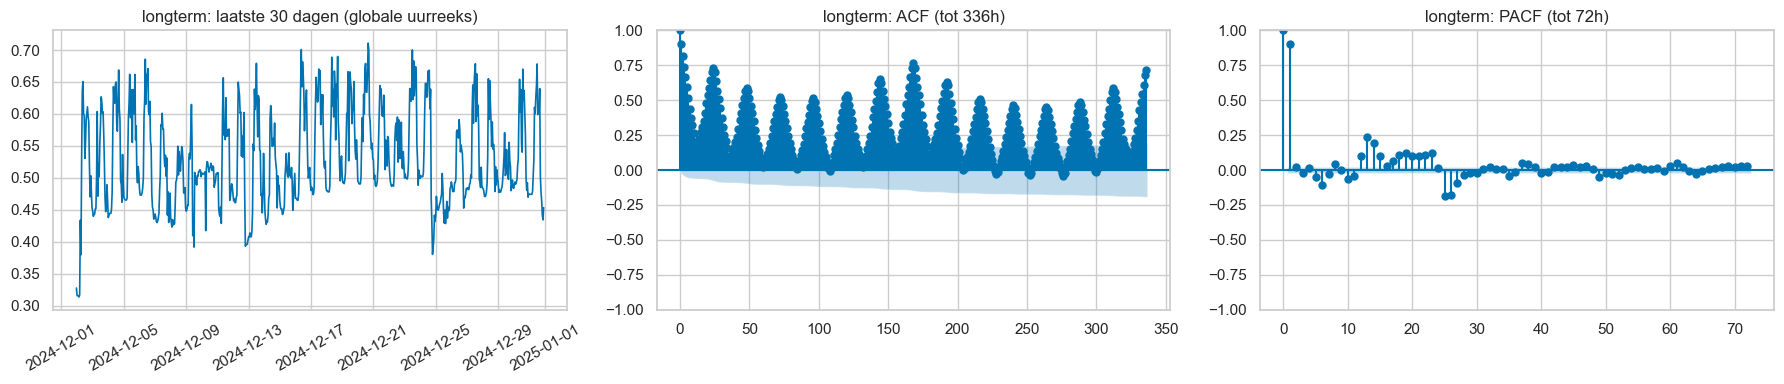

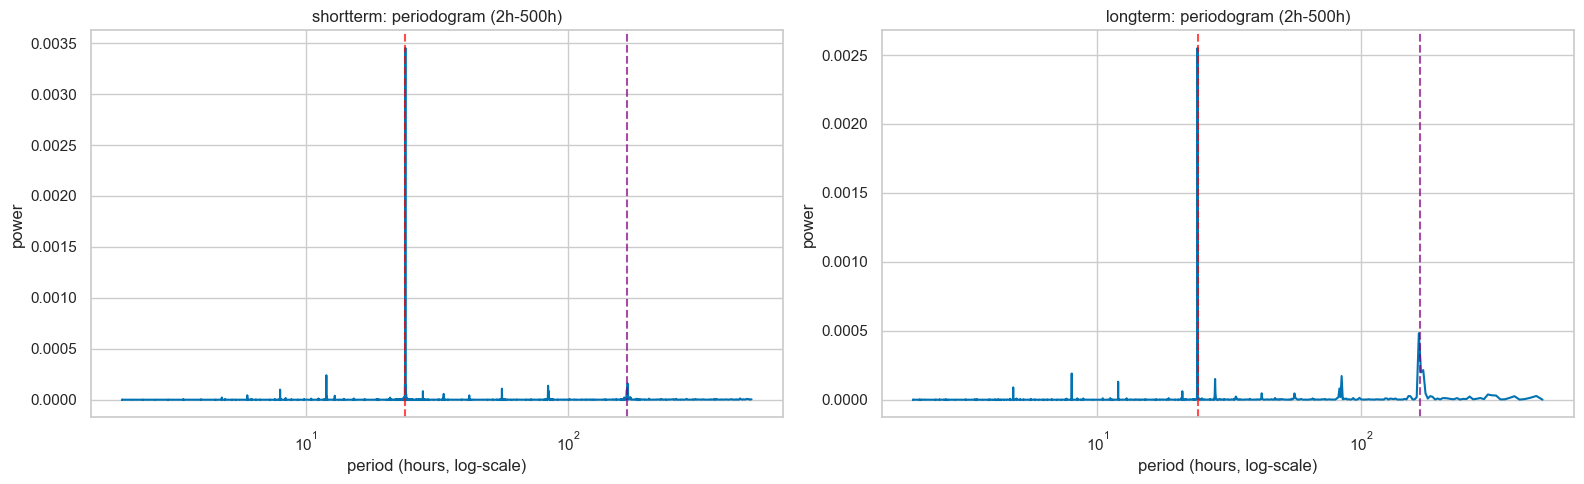

In [9]:
for dataset_label in ["shortterm", "longterm"]:
    key = f"{dataset_label}_global"
    s = series_catalog[key]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Reeksoverzicht (laatste 30 dagen voor leesbaarheid)
    tail = s.iloc[-24 * 30 :]
    axes[0].plot(tail.index, tail.values, linewidth=1.2)
    axes[0].set_title(f"{dataset_label}: laatste 30 dagen (globale uurreeks)")
    axes[0].tick_params(axis="x", rotation=30)

    plot_acf(s, lags=24 * 14, ax=axes[1])
    axes[1].set_title(f"{dataset_label}: ACF (tot 336h)")

    plot_pacf(s, lags=24 * 3, method="ywm", ax=axes[2])
    axes[2].set_title(f"{dataset_label}: PACF (tot 72h)")

    plt.tight_layout()
    plt.show()

# Periodogram visualisatie voor globale reeksen
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    s = series_catalog[f"{dataset_label}_global"]
    x = s.values - s.values.mean()
    freqs, power = signal.periodogram(x, fs=1.0, scaling="spectrum")
    valid = freqs > 0
    periods = 1 / freqs[valid]
    power = power[valid]

    keep = (periods >= 2) & (periods <= 500)
    ax.plot(periods[keep], power[keep])
    ax.set_xscale("log")
    ax.set_title(f"{dataset_label}: periodogram (2h-500h)")
    ax.set_xlabel("period (hours, log-scale)")
    ax.set_ylabel("power")
    ax.axvline(24, color="red", linestyle="--", alpha=0.7)
    ax.axvline(168, color="purple", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretatie**

ACF-waarden op 24 uur en 168 uur zijn consistent positief in representatieve reeksen, en periodogrammen tonen duidelijke pieken rond daily en weekly periodiciteit. Dat ondersteunt een robuuste seizoenscomponent.

De stationariteitstests moeten voorzichtig gelezen worden: op ruwe reeksen is de ADF/KPSS-combinatie vaak gemengd (typisch bij trend/structuurbreuken/seizoenscomponenten), terwijl seizoensdifferentiatie (`24h`, `168h`) veel vaker consistente stationariteitssignalen geeft.

**Hypothese status**
- H-T2: **Supported** (duidelijke 24u- en 168u-signaturen).
- H-T3: **Partially supported** (ruwe reeks geeft gemengde signalen; na seizoensdifferentiatie duidelijk stationairder).

**Volgende logische stap**
- De sterkte van daily/weekly seasonality expliciet kwantificeren voor feature-encodingbeslissingen.

## 6. Is seasonality sterk genoeg voor cyclische encoding?

In [10]:
strength_rows = []

for dataset_label, df in filtered_dfs.items():
    y = df["occupancy_rate"].astype(float)
    grand_mean = float(y.mean())
    tss = float(((y - grand_mean) ** 2).sum())

    pred_hour = df.groupby("hour")["occupancy_rate"].transform("mean")
    pred_hour_weekday = df.groupby(["weekday_int", "hour"])["occupancy_rate"].transform("mean")

    r2_hour = 1 - float(((y - pred_hour) ** 2).sum()) / tss
    r2_hour_weekday = 1 - float(((y - pred_hour_weekday) ** 2).sum()) / tss

    s_global = series_catalog[f"{dataset_label}_global"]
    power_share = (
        periodogram_share_summary.loc[periodogram_share_summary["series"] == f"{dataset_label}_global"]
        .set_index("band")["power_share_pct"]
        .to_dict()
    )

    hourly_profile = df.groupby("hour")["occupancy_rate"].mean()

    strength_rows.append(
        {
            "dataset_label": dataset_label,
            "r2_hour_only": r2_hour,
            "r2_hour_weekday": r2_hour_weekday,
            "incremental_r2_weekday_given_hour": r2_hour_weekday - r2_hour,
            "daily_amplitude_max_minus_min": float(hourly_profile.max() - hourly_profile.min()),
            "power_share_24h_pct": float(power_share.get("24h(+/-0.5)", np.nan)),
            "power_share_168h_pct": float(power_share.get("168h(+/-8)", np.nan)),
        }
    )

seasonality_strength = pd.DataFrame(strength_rows).set_index("dataset_label")
display(seasonality_strength.round(4))

,r2_hour_only,r2_hour_weekday,incremental_r2_weekday_given_hour,daily_amplitude_max_minus_min,power_share_24h_pct,power_share_168h_pct
dataset_label,,,,,,
shortterm,0.1052,0.1277,0.0225,0.2697,58.9135,3.782
longterm,0.0422,0.0616,0.0195,0.1393,37.1644,12.835


**Interpretatie**

De verklaringskracht van uur en hour×weekday is duidelijk niet nul, en de spectra rond 24u/168u bevestigen dat cyclische tijdsinformatie substantieel is. Shortterm toont doorgaans sterkere daily-signalen; longterm behoudt wel duidelijke weekly-component.

Conclusie: cyclische encodings (sin/cos voor uur en weekcyclus) zijn inhoudelijk verdedigbaar, maar waarschijnlijk nuttiger in interactie met segmentatie (dataset/tier/parking) dan als uniforme globale features.

**Hypothese status**
- H-T5: **Supported**.
- H-T6: **Verder ondersteund** (verschillen in seasonality-sterkte tussen datasets).

**Volgende logische stap**
- COVID-/structuurbreuksignalen descriptief en voorzichtig onderzoeken.

## 7. COVID- en structuurbreuksignalen (descriptief, niet-causaal)

Shortterm jaar-signature table


,n_obs,mean_occ,std_occ,q95_occ,pct_ge_90,weekend_minus_weekday
year,,,,,,
2019,33000,0.4133,0.2549,0.9149,5.8152,-0.0066
2020,32741,0.3814,0.2589,0.8889,4.4104,-0.0182
2023,39980,0.4205,0.2770,0.8936,4.5373,0.0221
2024,57116,0.3090,0.2747,0.9333,6.1244,0.0252
2025,87600,0.4008,0.2904,0.9926,8.7648,0.0235


Shortterm jaar-ACF signatures


,missing_pct_before_fill,acf_24,acf_168
year,,,
2019,0.7420,0.7313,0.8109
2020,0.0455,0.8164,0.7984
2023,0.9703,0.7154,0.6977
2024,0.0000,0.7680,0.8339
2025,0.0000,0.7679,0.8547


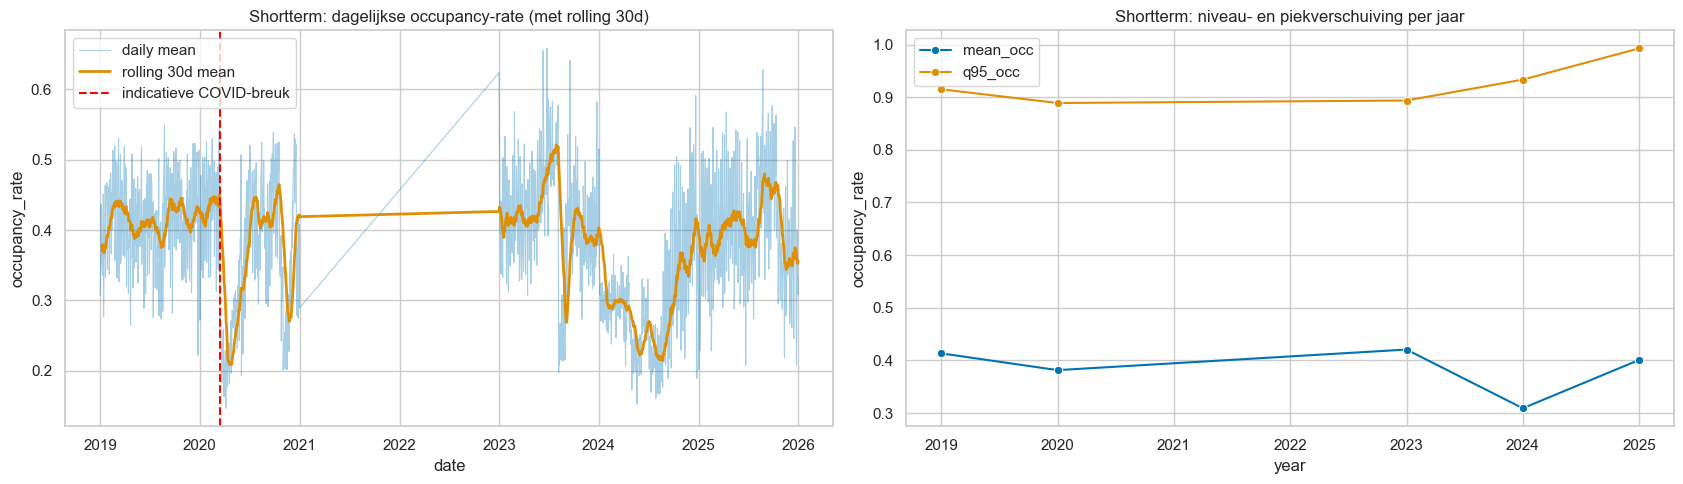

In [11]:
st = filtered_dfs["shortterm"].copy()

# Dagelijkse globale reeks
st_daily = st.groupby("date_only")["occupancy_rate"].mean().sort_index().to_frame(name="daily_mean_occ")
st_daily["rolling_30d"] = st_daily["daily_mean_occ"].rolling(30, min_periods=7).mean()

# Jaarlijke temporal signatures
year_signature = (
    st.groupby("year")
    .agg(
        n_obs=("occupancy_rate", "size"),
        mean_occ=("occupancy_rate", "mean"),
        std_occ=("occupancy_rate", "std"),
        q95_occ=("occupancy_rate", lambda s: s.quantile(0.95)),
        pct_ge_90=("occupancy_rate", lambda s: (s >= 0.9).mean() * 100),
        weekend_minus_weekday=("is_weekend", lambda s: np.nan),
    )
)

# Weekend-weekday verschil per jaar
ww_gap = (
    st.groupby(["year", "is_weekend"])["occupancy_rate"]
    .mean()
    .unstack("is_weekend")
)
if {False, True}.issubset(set(ww_gap.columns)):
    year_signature["weekend_minus_weekday"] = ww_gap[True] - ww_gap[False]

# Jaarlijkse ACF-signaturen op globale uurreeks
acf_year_rows = []
for year, grp in st.groupby("year"):
    s, missing_pct = make_hourly_mean_series(grp)
    a = acf(s, nlags=168, fft=True)
    acf_year_rows.append(
        {
            "year": int(year),
            "missing_pct_before_fill": missing_pct,
            "acf_24": float(a[24]),
            "acf_168": float(a[168]),
        }
    )
acf_year_df = pd.DataFrame(acf_year_rows).set_index("year").sort_index()

print("Shortterm jaar-signature table")
display(year_signature.round(4))

print("Shortterm jaar-ACF signatures")
display(acf_year_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].plot(st_daily.index, st_daily["daily_mean_occ"], alpha=0.35, linewidth=0.8, label="daily mean")
axes[0].plot(st_daily.index, st_daily["rolling_30d"], linewidth=2.0, label="rolling 30d mean")
axes[0].axvline(pd.Timestamp("2020-03-15"), color="red", linestyle="--", label="indicatieve COVID-breuk")
axes[0].set_title("Shortterm: dagelijkse occupancy-rate (met rolling 30d)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("occupancy_rate")
axes[0].legend()

sns.lineplot(
    data=year_signature.reset_index(),
    x="year",
    y="mean_occ",
    marker="o",
    ax=axes[1],
    label="mean_occ",
)
sns.lineplot(
    data=year_signature.reset_index(),
    x="year",
    y="q95_occ",
    marker="o",
    ax=axes[1],
    label="q95_occ",
)
axes[1].set_title("Shortterm: niveau- en piekverschuiving per jaar")
axes[1].set_ylabel("occupancy_rate")

plt.tight_layout()
plt.show()

**Interpretatie**

Descriptief zijn er duidelijke niveauverschuivingen rond en na 2020, maar de aanwezigheid van 24u/168u-autocorrelatie in meerdere jaren suggereert dat tijdsstructuur niet verdwijnt. Met andere woorden: er zijn aanwijzingen voor regime-/niveauverandering bovenop een blijvende seizoenscomponent.

Door coverage- en compositieshift (welke parkings in welke jaren sterk vertegenwoordigd zijn) is een causale of harde breukclaim niet verdedigbaar in deze fase.

**Hypothese status**
- H-T4: **Partially supported** (jaarafwijkingen zichtbaar, tijdsstructuur blijft deels herkenbaar).
- H-T7: **Verder ondersteund** (structuurverschuivingen vereisen tijdsbewuste validatie en holdout-keuzes).

**Volgende logische stap**
- Hypothese-evaluatie afronden en vertalen naar concrete Phase 3 feature/transformatie-aanbevelingen.

## 8. Hypothese-evaluatie en aanbevelingen

In [12]:
hypothesis_status = pd.DataFrame(
    [
        {
            "hypothesis": "H-T1",
            "status": "supported",
            "evidence_summary": "Intradagprofielen verschillen naar weekday/weekend en centrum-vs-rand in beide datasets.",
        },
        {
            "hypothesis": "H-T2",
            "status": "supported",
            "evidence_summary": "ACF en periodogram tonen duidelijke periodiciteit rond 24u en 168u.",
        },
        {
            "hypothesis": "H-T3",
            "status": "partially supported",
            "evidence_summary": "Ruwe reeks geeft gemengde ADF/KPSS-signalen; na 24u/168u differencing wordt stationariteit consistenter.",
        },
        {
            "hypothesis": "H-T4",
            "status": "partially supported",
            "evidence_summary": "2020 wijkt af in niveau/distributie; seizoenssignatuur blijft aanwezig maar profielgelijkenis varieert per referentiejaar.",
        },
        {
            "hypothesis": "H-T5",
            "status": "supported",
            "evidence_summary": "R2(hour, hour×weekday) en spectrale pieken bevestigen bruikbare dagelijkse/wekelijkse cycli.",
        },
        {
            "hypothesis": "H-T6",
            "status": "supported",
            "evidence_summary": "Shortterm en longterm tonen verschillende weekend-effecten en seasonality-sterkte.",
        },
        {
            "hypothesis": "H-T7",
            "status": "supported",
            "evidence_summary": "Jaarverschillen en compositieshift impliceren year-aware train/holdoutstrategie.",
        },
    ]
)

display(hypothesis_status)

,hypothesis,status,evidence_summary
0,H-T1,supported,Intradagprofielen verschillen naar weekday/wee...
1,H-T2,supported,ACF en periodogram tonen duidelijke periodicit...
2,H-T3,partially supported,Ruwe reeks geeft gemengde ADF/KPSS-signalen; n...
3,H-T4,partially supported,2020 wijkt af in niveau/distributie; seizoenss...
4,H-T5,supported,"R2(hour, hour×weekday) en spectrale pieken bev..."
5,H-T6,supported,Shortterm en longterm tonen verschillende week...
6,H-T7,supported,Jaarverschillen en compositieshift impliceren ...


### Welke temporele features lijken logisch voor Phase 3?

1. Cyclische encodings: `sin/cos(hour)`, `sin/cos(weekday)`, eventueel `sin/cos(month)`.
2. Seizoenslags en verschillen: `lag_24`, `lag_168`, `diff_24`, `diff_168`, en rolling-statistieken (24h/168h vensters).
3. Piek- en regimefeatures: indicatoren voor hoge druk (bijv. `occupancy_rate >= 0.9`), lokale q95/q99-context.
4. Segmentatie-interacties: tijdsfeatures kruisen met `tier_temporal`, `parking_id`-baseline en `dataset_label`.
5. Jaar/regime-indicatoren voor structurele shifts (minstens year-fixed effects of periodedummies).

### Aanbevolen transformaties en segmentaties

1. Modelleer shortterm en longterm minstens met aparte feature treatment (en waarschijnlijk aparte modellen) wegens temporele heterogeniteit.
2. Gebruik tijdsgebaseerde validatie (rolling/blocked split), niet random CV.
3. Voor inferentie-gevoelige analyses: reproduceer kernresultaten op strengere subset zonder `flag_frozen_sensor` (consequentie uit `eda_00`).
4. Rapporteer steeds jaar- en coverage-context bij temporele conclusies om compositiebias zichtbaar te houden.

## Key findings
1. De data tonen duidelijke daily en weekly temporal structuur, met sterke signalen rond 24u en 168u.
2. Tijdsdynamiek verschilt tussen shortterm en longterm; uniforme tijdsbehandeling is dus risicovol.
3. Jaarverschillen zijn substantieel en beïnvloeden niveau, piekgedrag en profielvergelijking.
4. Seizoensdifferentiatie maakt stationariteitstests consistenter, wat nuttig is voor latere modeldiagnostiek.

## Implications for feature engineering
1. Prioriteer cyclische tijdsfeatures en seizoenslags als basisset.
2. Voeg jaar/regime-indicatoren en interacties met locatie/tier toe om structurele heterogeniteit op te vangen.
3. Overweeg dataset-specifieke feature pipelines (shortterm versus longterm).
4. Gebruik kwaliteitsflags uit `eda_00` als sensitiviteitslaag in feature-evaluatie.

## Open questions for next notebook
1. Welke ruimtelijke segmenten versterken of verzwakken de gevonden daily/weekly patronen?
2. In welke mate verklaren externe factoren (weer, events, kalender) de jaar-op-jaar niveauverschuivingen?
3. Welke temporele features blijven stabiel performant over verschillende jaarholdouts?
4. Is een hiërarchische modellering (global + parking-level) nodig om temporal heterogeniteit correct te capteren?